In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt
from sklearn.tree import _tree
from sklearn import metrics, tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import numpy as np
from sklearn.metrics.pairwise import euclidean_distances

In [2]:
def tree_to_code(tree, feature_names):                    # code from StackOverFlow by paulkernfeld
    tree_ = tree.tree_                                    # convert tree object to portable code to use anywhere
    feature_name = [
        feature_names[i] if i != _tree.TREE_UNDEFINED else "undefined!"
        for i in tree_.feature
    ]
    print("def tree({}):".format(", ".join(feature_names)))

    def recurse(node, depth):
        indent = "  " * depth
        if tree_.feature[node] != _tree.TREE_UNDEFINED:
            name = feature_name[node]
            threshold = tree_.threshold[node]
            print("{}if {} <= {}:".format(indent, name, threshold))
            recurse(tree_.children_left[node], depth + 1)
            print("{}elif {} > {}".format(indent, name, threshold))
            recurse(tree_.children_right[node], depth + 1)
        else:
            print("{}return {}".format(indent, tree_.value[node]))
    recurse(0, 1) 

In [3]:
data = pd.read_excel('R1_ALL.xlsx')

In [4]:
X_cord = data['X'].values
Y_cord = data['Y'].values

# Reshape X_cord and Y_cord to have a shape of (n_samples, 1)
X_cord = X_cord.reshape(-1, 1)
Y_cord = Y_cord.reshape(-1, 1)

# Concatenate X_cord and Y_cord to create a 2D array of shape (n_samples, 2)
points = np.concatenate((X_cord, Y_cord), axis=1)

# Initialize an empty array to store the weights
weights = np.zeros(len(data))

# Iterate over each point in the dataset
for i in range(len(data)):
    # Select the coordinates of the current point
    center_point = points[i]

    # Calculate the displacement lengths between the current point and all other points
    distances = euclidean_distances(points, [center_point])

    # Get the indices of the 10 closest points to the current point
    closest_indices = np.argsort(distances.flatten())[1:11]  # Exclude the center point itself

    # Calculate the weights based on the displacement lengths
    point_weights = 1 / distances[closest_indices]

    # Assign the weights to the corresponding indices
    weights[closest_indices] = point_weights.flatten()

# Assign the calculated weights to the 'weights' column in the dataset
data['weights'] = weights

# Save the dataset to the 'R1_ALL.xlsx' file
data.to_excel('R1_ALL.xlsx', index=False)


In [5]:
# Add categorical labels based on thresholds
data['L_Cat'] = pd.cut(data['L'], bins=[0, 20, float('inf')], labels=['Insignificant', '20 m Event'])

In [6]:
pred = data[['TWI', 'S', 'DFC']]
res = data['L_Cat']

In [7]:
pred_train, pred_test, res_train, res_test = train_test_split(pred, res, test_size=0.3, random_state=500)
train_weights = data.loc[pred_train.index, 'weights']

In [8]:
# Create an instance of the DecisionTreeClassifier and fit it to the training data
dt_classifier = DecisionTreeClassifier(class_weight= None, criterion='gini', max_depth=5,
            max_features=None, max_leaf_nodes=8,
            min_impurity_decrease=0.0,
            min_samples_leaf=1, min_samples_split=2,
            min_weight_fraction_leaf=0.0,
            random_state=500, splitter='best')
dt_classifier.fit(pred_train, res_train, sample_weight=train_weights)

DecisionTreeClassifier(max_depth=5, max_leaf_nodes=8, random_state=500)

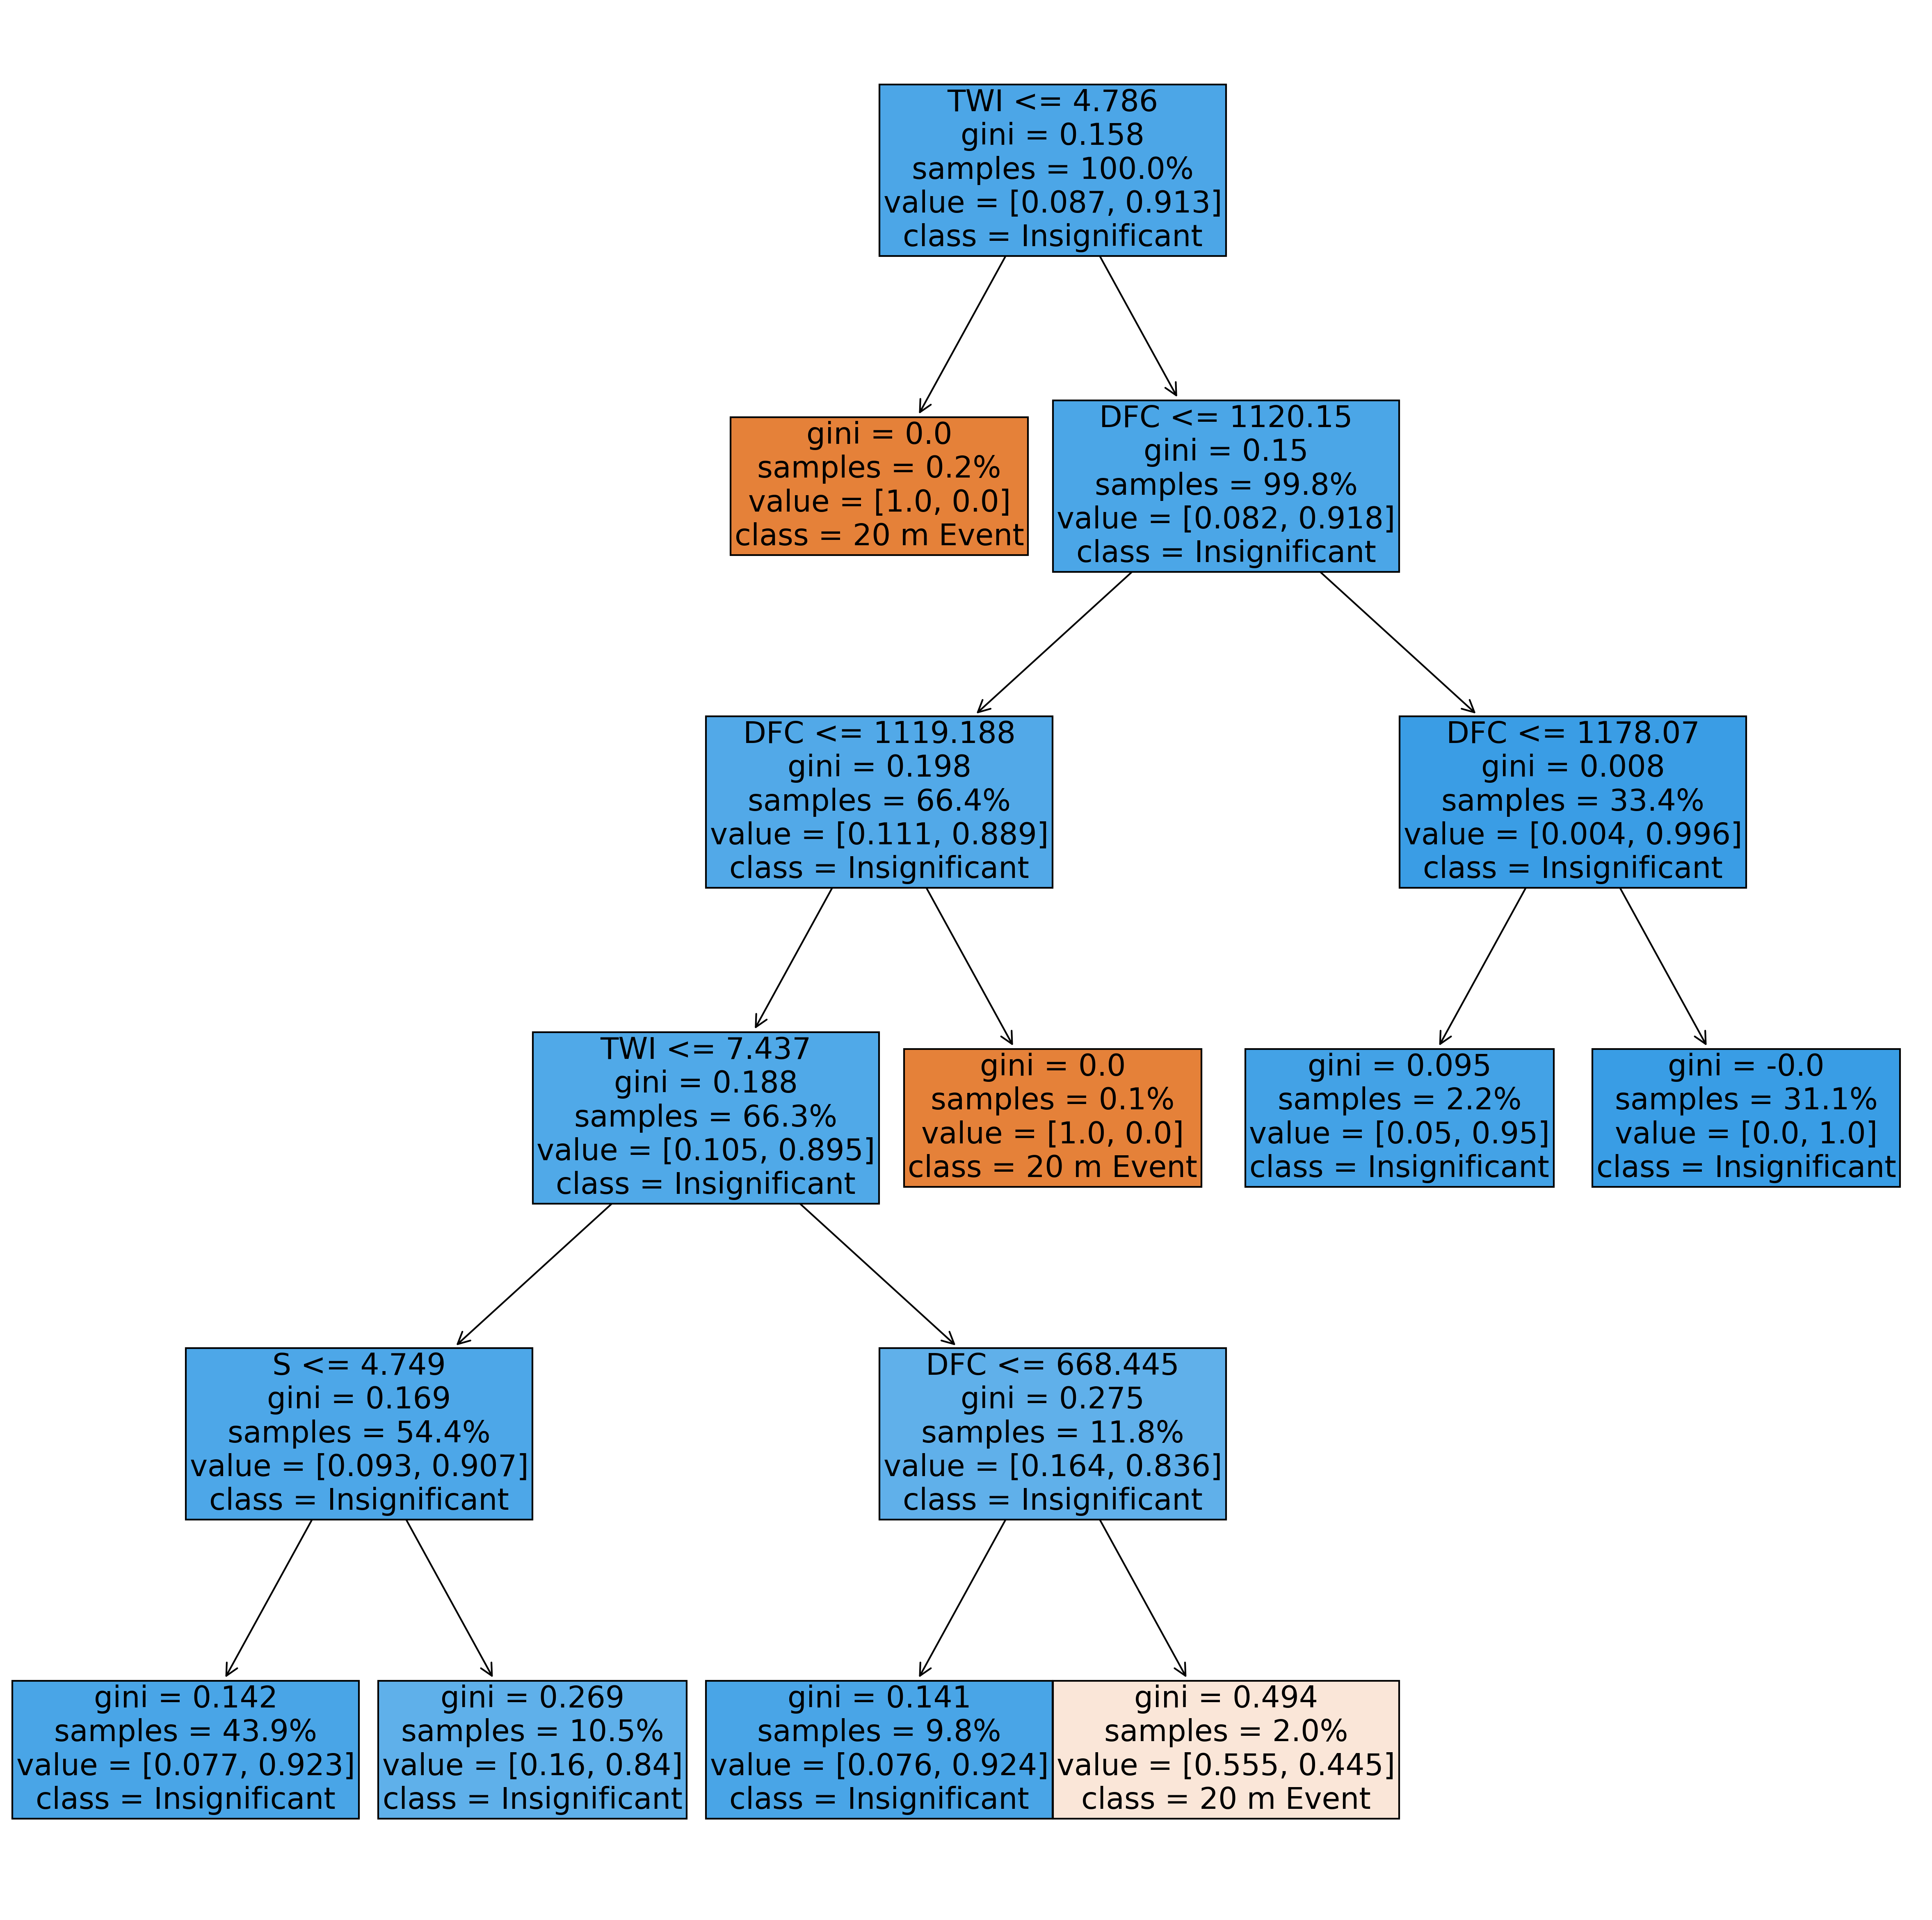

In [10]:
# Visualize the decision tree
plt.figure(figsize=(20, 20), dpi=300)
plt.rcParams.update({'font.size': 30})
_ = tree.plot_tree(dt_classifier, 
                   feature_names=list(pred),  
                   class_names=list(dt_classifier.classes_),
                   filled=True, proportion=True)
#plot_tree(dt_classifier, feature_names=pred.columns.tolist(), class_names=list(dt_classifier.classes_), filled=True)
# Save the plot as a PNG image
plt.savefig('decision_tree_20m_Event.png', dpi=1080)
plt.show()


In [11]:
tree_to_code(dt_classifier, list(pred))

def tree(TWI, S, DFC):
  if TWI <= 4.785914182662964:
    return [[0.02861561 0.        ]]
  elif TWI > 4.785914182662964
    if DFC <= 1120.1504516601562:
      if DFC <= 1119.1881103515625:
        if TWI <= 7.4373579025268555:
          if S <= 4.74890398979187:
            return [[0.19602441 2.35317558]]
          elif S > 4.74890398979187
            return [[0.10142063 0.53258849]]
        elif TWI > 7.4373579025268555
          if DFC <= 668.4449462890625:
            return [[0.0392409  0.47496075]]
          elif DFC > 668.4449462890625
            return [[0.0642482  0.05155889]]
      elif DFC > 1119.1881103515625
        return [[0.02716332 0.        ]]
    elif DFC > 1120.1504516601562
      if DFC <= 1178.0702514648438:
        return [[0.00563233 0.1070075 ]]
      elif DFC > 1178.0702514648438
        return [[0.         1.35576587]]


In [12]:
# Predict the target variable for the test data
res_pred = dt_classifier.predict(pred_test)

In [13]:
# Evaluate the performance of the model by comparing the predicted values with the actual values
accuracy = metrics.accuracy_score(res_test, res_pred)
print("Accuracy:", accuracy)

Accuracy: 0.907103825136612


In [14]:
# Calculate evaluation metrics
accuracy = metrics.accuracy_score(res_test, res_pred)
precision = metrics.precision_score(res_test, res_pred, average='weighted')
recall = metrics.recall_score(res_test, res_pred, average='weighted')
f1_score = metrics.f1_score(res_test, res_pred, average='weighted')

# Calculate feature importance
feature_importance = dt_classifier.feature_importances_

# Print the evaluation metrics and feature importance
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1_score)
print("Feature Importance:")
for feature, importance in zip(pred.columns, feature_importance):
    print(feature, ":", importance)

Accuracy: 0.907103825136612
Precision: 0.8664493119652232
Recall: 0.907103825136612
F1 Score: 0.8863106142452284
Feature Importance:
TWI : 0.30995357908901555
S : 0.040766241625415436
DFC : 0.6492801792855691


In [15]:
# Calculate the range for each predictor feature within each response category
category_ranges = data.groupby('L_Cat')[pred.columns].agg(['min', 'max'])
print("\nRange for each predictor feature within each response category:")
print(category_ranges)


Range for each predictor feature within each response category:
                    TWI                   S                   DFC             
                    min       max       min        max        min          max
L_Cat                                                                         
Insignificant  4.802809  8.626351  0.608323  11.928870   1.290900  3328.632088
20 m Event     4.769019  7.788997  1.056841  10.903402  20.963329  1176.583787


In [16]:
# Predict the target variable for the test data
res_pred_ALL = dt_classifier.predict(pred)
data['class'] = res_pred_ALL
data.to_excel('R1_ALL.xlsx', index=False)

In [17]:
accuracy = accuracy_score(res_test, res_pred)
print("Accuracy:", accuracy)

Accuracy: 0.907103825136612


In [18]:
confusion = confusion_matrix(res_test, res_pred)
TN = confusion[0, 0]
FP = confusion[0, 1]
FN = confusion[1, 0]
TP = confusion[1, 1]

print("Confusion Matrix:")
print("True Negatives (TN):", TN)
print("False Positives (FP):", FP)
print("False Negatives (FN):", FN)
print("True Positives (TP):", TP)


Confusion Matrix:
True Negatives (TN): 0
False Positives (FP): 25
False Negatives (FN): 9
True Positives (TP): 332


In [19]:
report = classification_report(res_test, res_pred)
print("Classification Report:")
print(report)

Classification Report:
               precision    recall  f1-score   support

   20 m Event       0.00      0.00      0.00        25
Insignificant       0.93      0.97      0.95       341

     accuracy                           0.91       366
    macro avg       0.46      0.49      0.48       366
 weighted avg       0.87      0.91      0.89       366



In [20]:
R3_data = pd.read_excel('R3_ALL.xlsx')
R3_data['R3_L_Cat'] = pd.cut(data['L'], bins=[0, 20, float('inf')], labels=['Insignificant', '20 m Event'])
R3_pred = R3_data[['TWI', 'S', 'DFC']]
R3_res = R3_data['R3_L_Cat']
R3_res_pred = dt_classifier.predict(R3_pred)
R3_data['class'] = R3_res_pred
R3_data.to_excel('R3_ALL.xlsx', index=False)

In [21]:
accuracy = accuracy_score(R3_res, R3_res_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8647594278283485
